In [53]:
import numpy as np
import pandas as pd

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import seaborn as sns
import matplotlib.pyplot as plt

### Feature engineering
For each column in cols, it adds:
- col_lag1, col_lag2: value from 1 and 2 days earlier.
- col_roll7, col_roll14: rolling mean over past 7/14 days (past-only, not using current day).
- col_diff1: day-to-day change (today - yesterday).

- It gives the model trend/history information, not just today’s raw value.

In [8]:
# -------------------------
# 1) Feature engineering
# -------------------------
def add_time_features(df: pd.DataFrame, cols, lags=(1,2), rolls=(7,14), diffs=(1,)):
    df = df.sort_values("date").copy()

    for col in cols:
        for lag in lags:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

        # Past-only rolling means: shift first, then roll
        s = df[col].shift(1)
        for w in rolls:
            df[f"{col}_roll{w}"] = s.rolling(w, min_periods=max(3, w//3)).mean()

        for d in diffs:
            df[f"{col}_diff{d}"] = df[col].diff(d)

    return df

In [30]:
# -------------------------
# 2) Read Data
# -------------------------
FILE_NAME = f"./data/garmin_data_180days/garmin_data_180days.csv"
df = pd.read_csv(FILE_NAME)

# basic shape + columns
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

# dtypes + non-null counts
# print("\nInfo:")
# print(df.info())

# missing values
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})
print("\nMissing values (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(20))

# duplicates
print("\nDuplicate rows:", df.duplicated().sum())


# numeric summary
# print("\nNumeric summary:")
# print(df.describe(include=[ "number" ]).T)

# categorical/text/date-like summary
# print("\nNon-numeric summary:")
# print(df.describe(include=[ "object", "category", "bool" ]).T)

# optional: if you have a date column named 'date'
if "date" in df.columns:
    tmp = df.copy()
    tmp["date"] = pd.to_datetime(tmp["date"], errors="coerce")
    print("\nDate range:", tmp["date"].min(), "to", tmp["date"].max())
    print("Invalid dates:", tmp["date"].isna().sum())

Shape: (181, 51)

Columns:
['date', 'hrv_rmssd', 'status', 'weekly_avg', 'lastnight_5min_high', 'feedback_phrase', 'resting_hr', 'total_sleep_hr', 'deep_sleep_hr', 'light_sleep_hr', 'rem_sleep_hr', 'awake_sleep_hr', 'avg_sleep_hr', 'avg_sleep_respiration', 'avg_sleep_stress', 'sleep_score', 'sleep_quality', 'sleep_feedback', 'sleep_need_baseline', 'sleep_need_actual', 'sleep_need_feedback', 'cycle_phase', 'maxStressLevel', 'avgStressLevel', 'charged', 'drained', 'monthlyLoadAerobicLow', 'monthlyLoadAerobicHigh', 'monthlyLoadAnaerobic', 'monthlyLoadAerobicLowTargetMin', 'monthlyLoadAerobicLowTargetMax', 'monthlyLoadAerobicHighTargetMin', 'monthlyLoadAerobicHighTargetMax', 'monthlyLoadAnaerobicTargetMin', 'monthlyLoadAnaerobicTargetMax', 'trainingBalanceFeedbackPhrase', 'trainingStatus', 'weeklyTrainingLoad', 'feedback', 'dailyTrainingLoadAcute', 'acwrPercent', 'acwrStatus', 'acwrStatusFeedback', 'dailyTrainingLoadChronic', 'minTrainingLoadChronic', 'maxTrainingLoadChronic', 'dailyAcuteC

In [45]:
# -------------------------
# 3) Build dataset
# -------------------------
target = "cycle_phase"

base_cols = [
    "date",
    "hrv_rmssd", "resting_hr", "avg_sleep_hr",
    "sleep_score", "total_sleep_hr", "deep_sleep_hr", "light_sleep_hr", "rem_sleep_hr", "awake_sleep_hr",
    "avg_sleep_stress",
    "avgStressLevel", "maxStressLevel",
    "dailyTrainingLoadChronic", "dailyTrainingLoadAcute", "acwrPercent",
    "drained", "charged",
]

base_cols = list(dict.fromkeys(base_cols))

needed = base_cols + [target]
missing = [c for c in needed if c not in df.columns]
print("Missing columns:", missing)

# df must have: date + base_cols + target
df_model = df[needed].copy()
df_model["date"] = pd.to_datetime(df_model["date"], errors="coerce")
df_model = df_model.sort_values("date")

# merge ovulation into fertile
df_model[target] = (
    df_model[target]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({"ovulation": "fertile"})
)

print(df_model[target].value_counts(dropna=False))

print("Duplicate columns:", df_model.columns[df_model.columns.duplicated()].tolist())
print("\nColumns:")
print(df_model.columns.tolist())

df_model = add_time_features(
    df_model,
    cols=["hrv_rmssd","resting_hr","sleep_score","avgStressLevel","dailyTrainingLoadChronic"],
)

# Drop rows where label missing (keep feature NaNs for imputer)
df_model = df_model.dropna(subset=[target]).reset_index(drop=True)

# missing values
missing_count = df_model.isna().sum().sort_values(ascending=False)
missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})
print("\nMissing values (top):")
print(missing_summary[missing_summary["missing_count"] > 0].head(20))

# Features: keep only numeric columns (or define explicitly)
feature_cols = [c for c in df_model.columns if c not in ["date", target]]
print("\nfeature_cols:", feature_cols)

X = df_model[feature_cols]
y = df_model[target]

# -------------------------
# 3) Time-based holdout split
# -------------------------
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

Missing columns: []
cycle_phase
luteal        65
follicular    43
fertile       42
menstrual     31
Name: count, dtype: int64
Duplicate columns: []

Columns:
['date', 'hrv_rmssd', 'resting_hr', 'avg_sleep_hr', 'sleep_score', 'total_sleep_hr', 'deep_sleep_hr', 'light_sleep_hr', 'rem_sleep_hr', 'awake_sleep_hr', 'avg_sleep_stress', 'avgStressLevel', 'maxStressLevel', 'dailyTrainingLoadChronic', 'dailyTrainingLoadAcute', 'acwrPercent', 'drained', 'charged', 'cycle_phase']

Missing values (top):
                                 missing_count  missing_pct
awake_sleep_hr                              30        16.57
avg_sleep_hr                                24        13.26
sleep_score_diff1                            7         3.87
hrv_rmssd_diff1                              7         3.87
hrv_rmssd_lag2                               5         2.76
sleep_score_lag2                             5         2.76
sleep_score_roll14                           4         2.21
resting_hr_roll14      

In [46]:
# -------------------------
# 4) Pipeline
# -------------------------
numeric_features = X_train.columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")), # fill nan values
            ("scaler", StandardScaler()), # standardize values so that scale does not affect
        ]), numeric_features),
    ],
    remainder="drop",
)

clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",
)

pipe = Pipeline([
    ("prep", preprocess),
    ("clf", clf),
])


In [47]:

# -------------------------
# 5) TimeSeries CV + grid
# -------------------------
tscv = TimeSeriesSplit(n_splits=5) # Splits data into 5 ordered train/validation folds

param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10], #Inverse of regularization strength; must be a positive float. Like in support vector machines, smaller values specify stronger regularization
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=tscv,
    scoring="f1_weighted",
    n_jobs=-1,
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
best = grid.best_estimator_

Best params: {'clf__C': 0.01}


In [51]:
# -------------------------
# 6) Evaluate
# -------------------------
y_pred = best.predict(X_test)

print(y_test.value_counts())
print(pd.Series(y_pred).value_counts())
print(classification_report(y_test, y_pred, zero_division=0))

cycle_phase
luteal        17
follicular     8
fertile        7
menstrual      5
Name: count, dtype: int64
menstrual     13
follicular    11
fertile        7
luteal         6
Name: count, dtype: int64
              precision    recall  f1-score   support

     fertile       0.43      0.43      0.43         7
  follicular       0.55      0.75      0.63         8
      luteal       0.83      0.29      0.43        17
   menstrual       0.31      0.80      0.44         5

    accuracy                           0.49        37
   macro avg       0.53      0.57      0.48        37
weighted avg       0.62      0.49      0.48        37



Text(0.5, 1.0, 'Confusion Matrix')

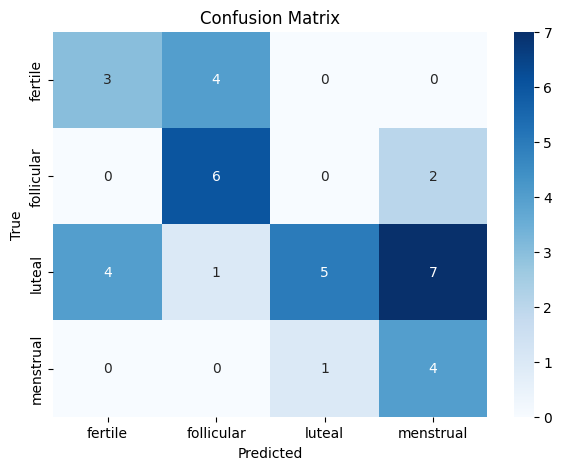

In [50]:
# 1) Confusion Matrix (Seaborn)
labels = np.unique(np.concatenate([np.array(y_test), np.array(y_pred)]))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
# plt.tight_layo